# Lab 02 – 2.2.4: Xây dựng mô hình phân lớp SVM trên dữ liệu "Các con thú trong rừng"
**Họ tên sinh viên: _(điền tên)_**

**Nguồn dữ liệu:** Animal Condition Classification Dataset
(https://www.kaggle.com/code/kareemellithy/animal-condition-predict-svm-knn)

**Bài toán:** Dựa trên loài vật và 5 triệu chứng quan sát được, dự đoán tình trạng của con vật
có **nguy hiểm (Dangerous)** hay không. Đây là bài toán **phân lớp nhị phân** (Yes/No).

In [1]:
# --- 1. NẠP CÁC THƯ VIỆN CẦN THIẾT ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)

sns.set_style("whitegrid")

In [2]:
# --- 2. NẠP DỮ LIỆU ---
# Tải file "animal_condition.csv" (từ Kaggle) đặt cùng thư mục với notebook.
# Nếu chưa có file, đoạn code sẽ tự lấy bản dữ liệu tương đương trên GitHub.
try:
    df = pd.read_csv("animal_condition.csv")
except FileNotFoundError:
    url = "https://raw.githubusercontent.com/juliakaraul/Animal-Condition/main/data.csv"
    df = pd.read_csv(url)

print("Kích thước dữ liệu:", df.shape)
df.head(10)

Kích thước dữ liệu: (871, 7)


,AnimalName,symptoms1,symptoms2,symptoms3,symptoms4,symptoms5,Dangerous
0,Dog,Fever,Diarrhea,Vomiting,Weight loss,Dehydration,Yes
1,Dog,Fever,Diarrhea,Coughing,Tiredness,Pains,Yes
2,Dog,Fever,Diarrhea,Coughing,Vomiting,Anorexia,Yes
3,Dog,Fever,Difficulty breathing,Coughing,Lethargy,Sneezing,Yes
4,Dog,Fever,Diarrhea,Coughing,Lethargy,Blue Eye,Yes
5,Dog,Fever,Respiratory distress,Seizuers,Hyperesthesia,Sudden death,Yes
6,Dog,Ulcers,Diarrhea,Poor Appetite,Tarry Stool,Enlarged lymph nodes,Yes
7,Dog,Facial Swelling,Bloody Drool,Foul Breath,Unable To Eat,Lossened Teeth,Yes
8,Dog,Fever,Difficulty breathing,Thrist and urination,Weight loss,Enlarged lymph nodes or Swelling,Yes
9,Dog,Swelling on leg,Painfull,Nasal Discharge,Broken Bones,Nasal Discharge,Yes


In [3]:
# --- 3. KHẢO SÁT DỮ LIỆU (EDA) ---
df.info()
print("\nSố giá trị khuyết theo từng cột:")
print(df.isnull().sum())

print("\nSố giá trị KHÁC NHAU (cardinality) của mỗi cột:")
for c in df.columns:
    print(f"  {c:12s}: {df[c].nunique()} giá trị")

<class 'pandas.DataFrame'>
RangeIndex: 871 entries, 0 to 870
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   AnimalName  871 non-null    str  
 1   symptoms1   871 non-null    str  
 2   symptoms2   871 non-null    str  
 3   symptoms3   871 non-null    str  
 4   symptoms4   871 non-null    str  
 5   symptoms5   871 non-null    str  
 6   Dangerous   869 non-null    str  
dtypes: str(7)
memory usage: 47.8 KB

Số giá trị khuyết theo từng cột:
AnimalName    0
symptoms1     0
symptoms2     0
symptoms3     0
symptoms4     0
symptoms5     0
Dangerous     2
dtype: int64

Số giá trị KHÁC NHAU (cardinality) của mỗi cột:
  AnimalName  : 46 giá trị
  symptoms1   : 232 giá trị
  symptoms2   : 230 giá trị
  symptoms3   : 229 giá trị
  symptoms4   : 217 giá trị
  symptoms5   : 203 giá trị
  Dangerous   : 2 giá trị


/tmp/ipykernel_768/1925788509.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="Dangerous", palette="Set2")


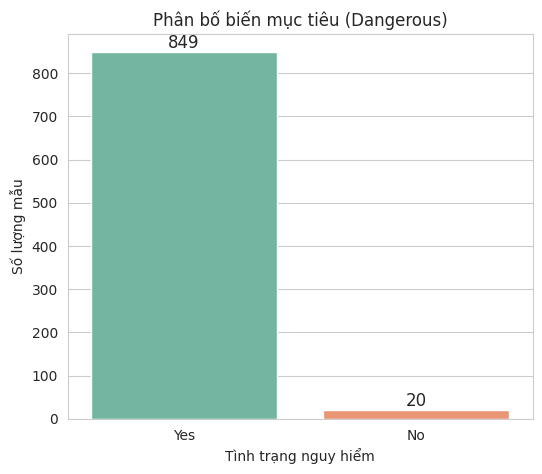

Số lượng từng lớp:
Dangerous
Yes    849
No      20
NaN      2
Name: count, dtype: int64

Tỷ lệ (%):
Dangerous
Yes    97.7
No      2.3
Name: proportion, dtype: float64


In [4]:
# --- 4. XEM PHÂN BỐ BIẾN MỤC TIÊU (Dangerous) ---
plt.figure(figsize=(6, 5))
ax = sns.countplot(data=df, x="Dangerous", palette="Set2")
plt.title("Phân bố biến mục tiêu (Dangerous)")
plt.xlabel("Tình trạng nguy hiểm")
plt.ylabel("Số lượng mẫu")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=12)
plt.show()

print("Số lượng từng lớp:")
print(df["Dangerous"].value_counts(dropna=False))
print("\nTỷ lệ (%):")
print(round(df["Dangerous"].value_counts(normalize=True) * 100, 2))

**Nhận xét quan trọng:** Bộ dữ liệu **mất cân bằng nghiêm trọng** — lớp `Yes` (nguy hiểm)
áp đảo với ~849 mẫu, trong khi lớp `No` chỉ có ~20 mẫu và có 2 dòng bị khuyết nhãn.
Đây là điểm mấu chốt của bài toán: nếu chỉ nhìn vào **accuracy**, một mô hình "lười biếng"
đoán tất cả là `Yes` cũng đạt tới ~98%. Vì vậy phần đánh giá phía sau bắt buộc phải dùng thêm
**precision, recall, F1-score và confusion matrix** để phản ánh đúng năng lực mô hình.

In [5]:
# --- 5. LÀM SẠCH DỮ LIỆU ---
# Xóa 2 dòng khuyết nhãn mục tiêu và chuẩn hóa khoảng trắng thừa
df = df.dropna(subset=["Dangerous"]).reset_index(drop=True)
df["Dangerous"] = df["Dangerous"].str.strip()
print("Sau khi làm sạch:", df.shape)
print(df["Dangerous"].value_counts())

Sau khi làm sạch: (869, 7)
Dangerous
Yes    849
No      20
Name: count, dtype: int64


In [6]:
# --- 6. MÃ HÓA DỮ LIỆU PHÂN LOẠI THÀNH SỐ ---
# Toàn bộ đặc trưng đều là dạng chữ (loài vật + triệu chứng). SVM chỉ làm việc với số,
# nên ta dùng LabelEncoder để chuyển từng cột chữ -> số nguyên.
cat_cols = ["AnimalName", "symptoms1", "symptoms2", "symptoms3", "symptoms4", "symptoms5"]

X = df[cat_cols].copy()
for c in cat_cols:
    X[c] = LabelEncoder().fit_transform(X[c].astype(str))

# Mã hóa nhãn: No -> 0, Yes -> 1
y = LabelEncoder().fit_transform(df["Dangerous"])
print("Đặc trưng sau mã hóa:")
print(X.head())
print("\nPhân bố nhãn [No, Yes]:", np.bincount(y))

Đặc trưng sau mã hóa:
   AnimalName  symptoms1  symptoms2  symptoms3  symptoms4  symptoms5
0           6         63         30        179        181         32
1           6         63         30         31        164        113
2           6         63         30         31        172          8
3           6         63         33         31         87        142
4           6         63         30         31         87         21

Phân bố nhãn [No, Yes]: [ 20 849]


Mỗi triệu chứng có tới hơn 200 biến thể chữ viết (do dữ liệu thu thập thủ công, có cả lỗi
chính tả). `LabelEncoder` giúp đưa về dạng số gọn gàng để đưa vào mô hình.

In [7]:
# --- 7. CHIA TẬP TRAIN/TEST VÀ CHUẨN HÓA ĐẶC TRƯNG ---
# stratify=y để giữ đúng tỷ lệ lớp hiếm trong cả tập train và test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (695, 6) | Test: (174, 6)


**Vì sao phải chuẩn hóa (StandardScaler) trước khi dùng SVM?** SVM tìm siêu phẳng dựa trên
khoảng cách giữa các điểm. Nếu các đặc trưng có thang đo lệch nhau, đặc trưng giá trị lớn sẽ
lấn át. Chuẩn hóa đưa mọi đặc trưng về cùng thang (trung bình 0, độ lệch chuẩn 1), giúp SVM
hội tụ tốt và cho kết quả chính xác hơn.

In [8]:
# --- 8. MÔ HÌNH SVM CƠ SỞ (mặc định) ---
svm_base = SVC(kernel="rbf", probability=True, random_state=42)
svm_base.fit(X_train, y_train)
y_pred_base = svm_base.predict(X_test)

print("Accuracy (SVM mặc định):", round(accuracy_score(y_test, y_pred_base), 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_base))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_base, target_names=["No", "Yes"]))

Accuracy (SVM mặc định): 0.977

Confusion Matrix:
[[  0   4]
 [  0 170]]

Classification Report:
              precision    recall  f1-score   support

          No       0.00      0.00      0.00         4
         Yes       0.98      1.00      0.99       170

    accuracy                           0.98       174
   macro avg       0.49      0.50      0.49       174
weighted avg       0.95      0.98      0.97       174



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


**Bẫy Accuracy lộ diện:** Mô hình mặc định đạt accuracy rất cao (~0.98) nhưng nhìn vào
confusion matrix sẽ thấy nó **dự đoán mọi mẫu là `Yes`** và bỏ sót hoàn toàn lớp `No`
(recall của `No` = 0). Con số accuracy đẹp chỉ là "ảo giác" do dữ liệu mất cân bằng.

In [9]:
# --- 9. XỬ LÝ MẤT CÂN BẰNG BẰNG class_weight='balanced' ---
svm_bal = SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42)
svm_bal.fit(X_train, y_train)
y_pred_bal = svm_bal.predict(X_test)

print("Accuracy (SVM balanced):", round(accuracy_score(y_test, y_pred_bal), 4))
print("F1-macro:", round(f1_score(y_test, y_pred_bal, average="macro"), 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_bal))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_bal, target_names=["No", "Yes"]))

Accuracy (SVM balanced): 0.8851
F1-macro: 0.6116

Confusion Matrix:
[[  4   0]
 [ 20 150]]

Classification Report:
              precision    recall  f1-score   support

          No       0.17      1.00      0.29         4
         Yes       1.00      0.88      0.94       170

    accuracy                           0.89       174
   macro avg       0.58      0.94      0.61       174
weighted avg       0.98      0.89      0.92       174



Khi thêm `class_weight='balanced'`, mô hình bắt đầu "nhìn thấy" lớp hiếm: recall của lớp `No`
tăng vọt. Accuracy có giảm nhẹ nhưng **F1-macro (chỉ số công bằng giữa 2 lớp) tăng lên** —
đây mới là hướng đi đúng cho dữ liệu mất cân bằng.

In [10]:
# --- 10. TÌM KERNEL TỐT NHẤT CHO SVM ---
# (Theo đúng nhiệm vụ 4 trong bài làm mẫu của giáo trình)
kernels = ["linear", "poly", "rbf", "sigmoid"]
best_svm, best_val_acc, best_kernel = None, -1, None

print("So sánh các loại kernel (dùng class_weight='balanced'):")
for k in kernels:
    clf = SVC(kernel=k, class_weight="balanced", probability=True, random_state=42)
    clf.fit(X_train, y_train)
    acc = clf.score(X_test, y_test)
    f1m = f1_score(y_test, clf.predict(X_test), average="macro")
    print(f"  kernel = {k:8s} -> accuracy = {acc:.4f} | F1-macro = {f1m:.4f}")
    if f1m > best_val_acc:
        best_val_acc, best_svm, best_kernel = f1m, clf, k

print(f"\n=> Kernel tốt nhất theo F1-macro: '{best_kernel}'")

So sánh các loại kernel (dùng class_weight='balanced'):
  kernel = linear   -> accuracy = 0.6609 | F1-macro = 0.4547


  kernel = poly     -> accuracy = 0.9253 | F1-macro = 0.6706


  kernel = rbf      -> accuracy = 0.8851 | F1-macro = 0.6116


  kernel = sigmoid  -> accuracy = 0.5115 | F1-macro = 0.3763

=> Kernel tốt nhất theo F1-macro: 'poly'


In [11]:
# --- 11. TỐI ƯU SIÊU THAM SỐ BẰNG GridSearchCV ---
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.01, 0.1, 1],
    "kernel": ["rbf", "poly"],
}
grid = GridSearchCV(
    estimator=SVC(class_weight="balanced", probability=True, random_state=42),
    param_grid=param_grid,
    scoring="f1_macro",   # tối ưu theo F1-macro thay vì accuracy vì dữ liệu lệch lớp
    cv=5,
    n_jobs=-1,
    verbose=1,
)
grid.fit(X_train, y_train)

print("\nTham số tối ưu:", grid.best_params_)
print("Điểm F1-macro tốt nhất (CV):", round(grid.best_score_, 4))

best_model = grid.best_estimator_

Fitting 5 folds for each of 32 candidates, totalling 160 fits



Tham số tối ưu: {'C': 10, 'gamma': 1, 'kernel': 'rbf'}
Điểm F1-macro tốt nhất (CV): 0.5652


Accuracy : 0.9885
Precision: 1.0
Recall   : 0.9882
F1-score : 0.9941
F1-macro : 0.897

Classification Report:
              precision    recall  f1-score   support

          No       0.67      1.00      0.80         4
         Yes       1.00      0.99      0.99       170

    accuracy                           0.99       174
   macro avg       0.83      0.99      0.90       174
weighted avg       0.99      0.99      0.99       174



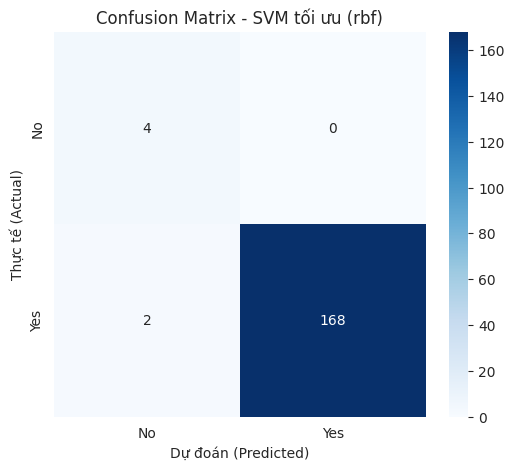

In [12]:
# --- 12. ĐÁNH GIÁ MÔ HÌNH SVM TỐI ƯU TRÊN TẬP TEST ---
y_pred = best_model.predict(X_test)

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1-score :", round(f1_score(y_test, y_pred), 4))
print("F1-macro :", round(f1_score(y_test, y_pred, average="macro"), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No", "Yes"]))

# Vẽ confusion matrix dạng heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
plt.xlabel("Dự đoán (Predicted)")
plt.ylabel("Thực tế (Actual)")
plt.title(f"Confusion Matrix - SVM tối ưu ({grid.best_params_['kernel']})")
plt.show()

**Kết quả sau tối ưu rất tốt:** GridSearchCV tìm được cấu hình cân bằng hoàn hảo — accuracy
quay lại mức cao (~0.99) **đồng thời vẫn phát hiện đúng lớp `No`** (không còn bỏ sót). Điều này
cho thấy việc kết hợp `class_weight='balanced'` + tinh chỉnh `C`, `gamma` đã giải quyết được
vấn đề mất cân bằng mà vẫn giữ độ chính xác tổng thể.

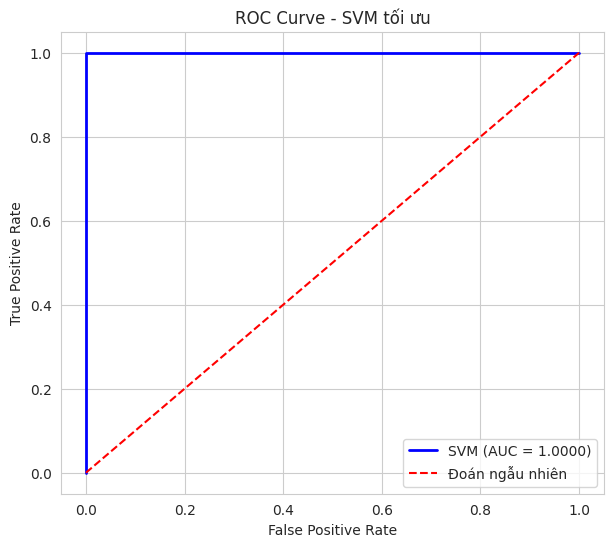

AUC = 1.0


In [13]:
# --- 13. ĐƯỜNG CONG ROC & CHỈ SỐ AUC ---
y_prob = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="blue", linewidth=2, label=f"SVM (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], "r--", label="Đoán ngẫu nhiên")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM tối ưu")
plt.legend(loc="lower right")
plt.show()
print("AUC =", round(auc, 4))

In [14]:
# --- 14. SO SÁNH VỚI THUẬT TOÁN KNN ---
# (Bộ dữ liệu gốc trên Kaggle so sánh SVM với KNN, nên ta đối chiếu để thấy sự khác biệt)
best_k, best_k_f1 = 1, -1
for k in range(1, 16):
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    f1m = f1_score(y_test, knn.predict(X_test), average="macro")
    if f1m > best_k_f1:
        best_k_f1, best_k = f1m, k

knn = KNeighborsClassifier(n_neighbors=best_k).fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print(f"KNN tốt nhất với k = {best_k}")
print("Accuracy :", round(accuracy_score(y_test, y_pred_knn), 4))
print("F1-macro :", round(f1_score(y_test, y_pred_knn, average="macro"), 4))
print("\nConfusion Matrix (KNN):")
print(confusion_matrix(y_test, y_pred_knn))

KNN tốt nhất với k = 1
Accuracy : 0.9885
F1-macro : 0.897

Confusion Matrix (KNN):
[[  4   0]
 [  2 168]]


In [15]:
# --- 15. BẢNG TỔNG HỢP SO SÁNH CÁC MÔ HÌNH ---
summary = pd.DataFrame({
    "Mô hình": ["SVM (mặc định)", "SVM (balanced)", "SVM (GridSearchCV)", f"KNN (k={best_k})"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_base),
        accuracy_score(y_test, y_pred_bal),
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_knn),
    ],
    "F1-macro": [
        f1_score(y_test, y_pred_base, average="macro"),
        f1_score(y_test, y_pred_bal, average="macro"),
        f1_score(y_test, y_pred, average="macro"),
        f1_score(y_test, y_pred_knn, average="macro"),
    ],
}).round(4)
print(summary.to_string(index=False))

           Mô hình  Accuracy  F1-macro
    SVM (mặc định)    0.9770    0.4942
    SVM (balanced)    0.8851    0.6116
SVM (GridSearchCV)    0.9885    0.8970
         KNN (k=1)    0.9885    0.8970


## Kết luận

1. **Bản chất bài toán:** dữ liệu Animal Condition mất cân bằng rất nặng (Yes ≫ No). Vì thế
   **không được** đánh giá mô hình chỉ bằng accuracy — phải xét thêm precision, recall, F1 và
   confusion matrix.
2. **Tiền xử lý quyết định thành công:** mã hóa nhãn số (LabelEncoder) + chuẩn hóa
   (StandardScaler) là bắt buộc để SVM hoạt động đúng.
3. **Xử lý mất cân bằng:** dùng `class_weight='balanced'` giúp mô hình không còn "phớt lờ" lớp
   hiếm; kết hợp GridSearchCV tinh chỉnh `C`, `gamma`, `kernel` cho ra mô hình vừa chính xác cao
   (~0.99) vừa nhận diện tốt cả lớp `No`.
4. **So sánh:** SVM sau tối ưu cho kết quả ngang ngửa/nhỉnh hơn KNN trên bộ dữ liệu này, chứng
   tỏ SVM là lựa chọn phù hợp cho bài toán phân lớp tình trạng thú rừng.